Limit on Planetary Companions from Doppler Surveys of Nearby Stars - Howard, Andrew W.; Fulton, Benjamin J.

In [1]:
from astropy.table import Table
import matplotlib.pyplot as mpl
import numpy as np

CurveData = Table.read("RadialVelocityCurveData274.tbl.txt", format="ascii")

# HJD (days) | Radial_Velocity (m/s) | Radial_Velocity_Uncertainty (m/s)

In [2]:
from scipy.optimize import curve_fit

def sinusoid(t, A, omega, phi, C):
    return A * np.sin(omega * t + phi) + C

t = CurveData["HJD"]
t_mean = np.mean(t)
t = t - t_mean
v = CurveData["Radial_Velocity"]
v_err = CurveData["Radial_Velocity_Uncertainty"]

A_guess = (np.max(v) - np.min(v)) / 2
omega_guess = 2 * np.pi / (t[np.argmax(v)] - t[np.argmin(v)])
phi_guess = 0
C_guess = np.mean(v)

initial_guess = [A_guess, omega_guess, phi_guess, C_guess]

popt, pcov = curve_fit(
    sinusoid,
    t,
    v,
    sigma=v_err,
    absolute_sigma=True,
    p0=initial_guess
)

t_fit = np.linspace(np.min(t), np.max(t), 1000)
v_fit = sinusoid(t_fit, *popt)

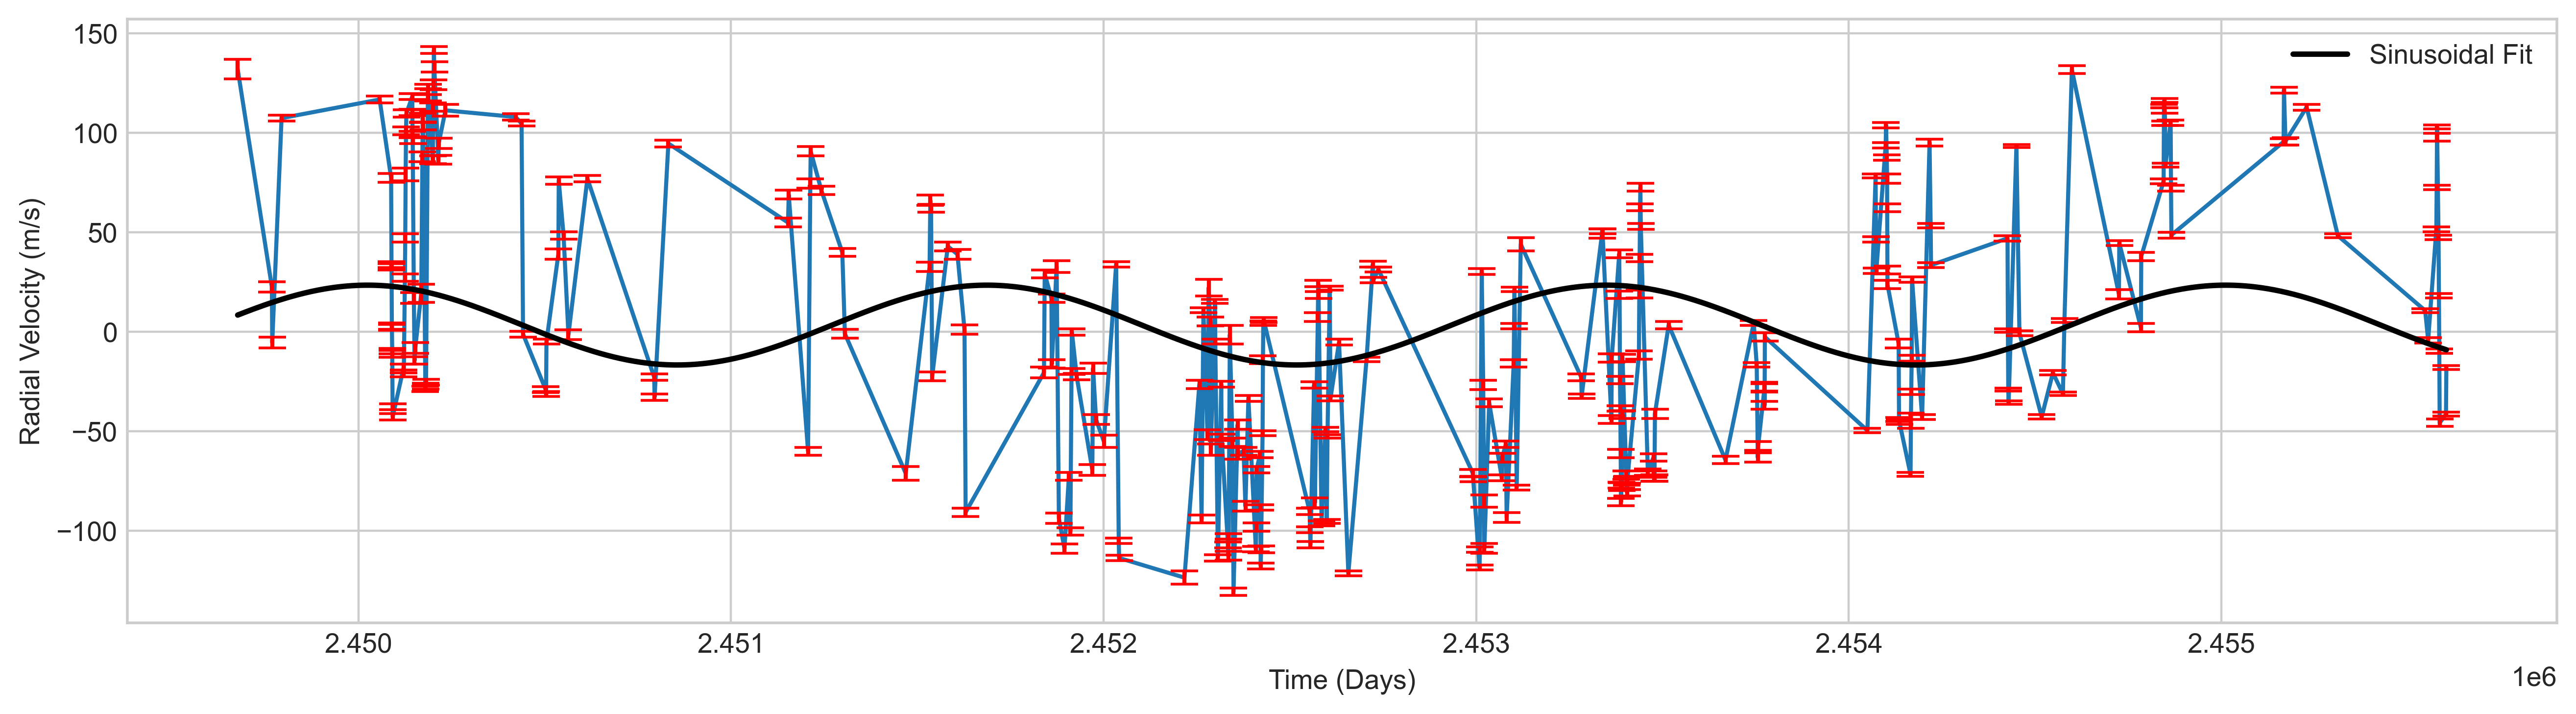

In [3]:
mpl.style.use('seaborn-v0_8-whitegrid')
mpl.figure(figsize=(16, 4), dpi=400)
mpl.plot(CurveData["HJD"], CurveData["Radial_Velocity"])
mpl.errorbar(CurveData["HJD"], CurveData["Radial_Velocity"], xerr=None, yerr=CurveData["Radial_Velocity_Uncertainty"], fmt="none", ecolor="red", barsabove=True, capsize=5)
mpl.xlabel("Time (Days)")
mpl.ylabel("Radial Velocity (m/s)")

t_fit = np.linspace(np.min(t), np.max(t), 1000)
v_fit = sinusoid(t_fit, *popt)

mpl.plot(t_fit + np.mean(CurveData["HJD"]), v_fit, color="black", linewidth=2, label="Sinusoidal Fit")
mpl.legend()

mpl.show()

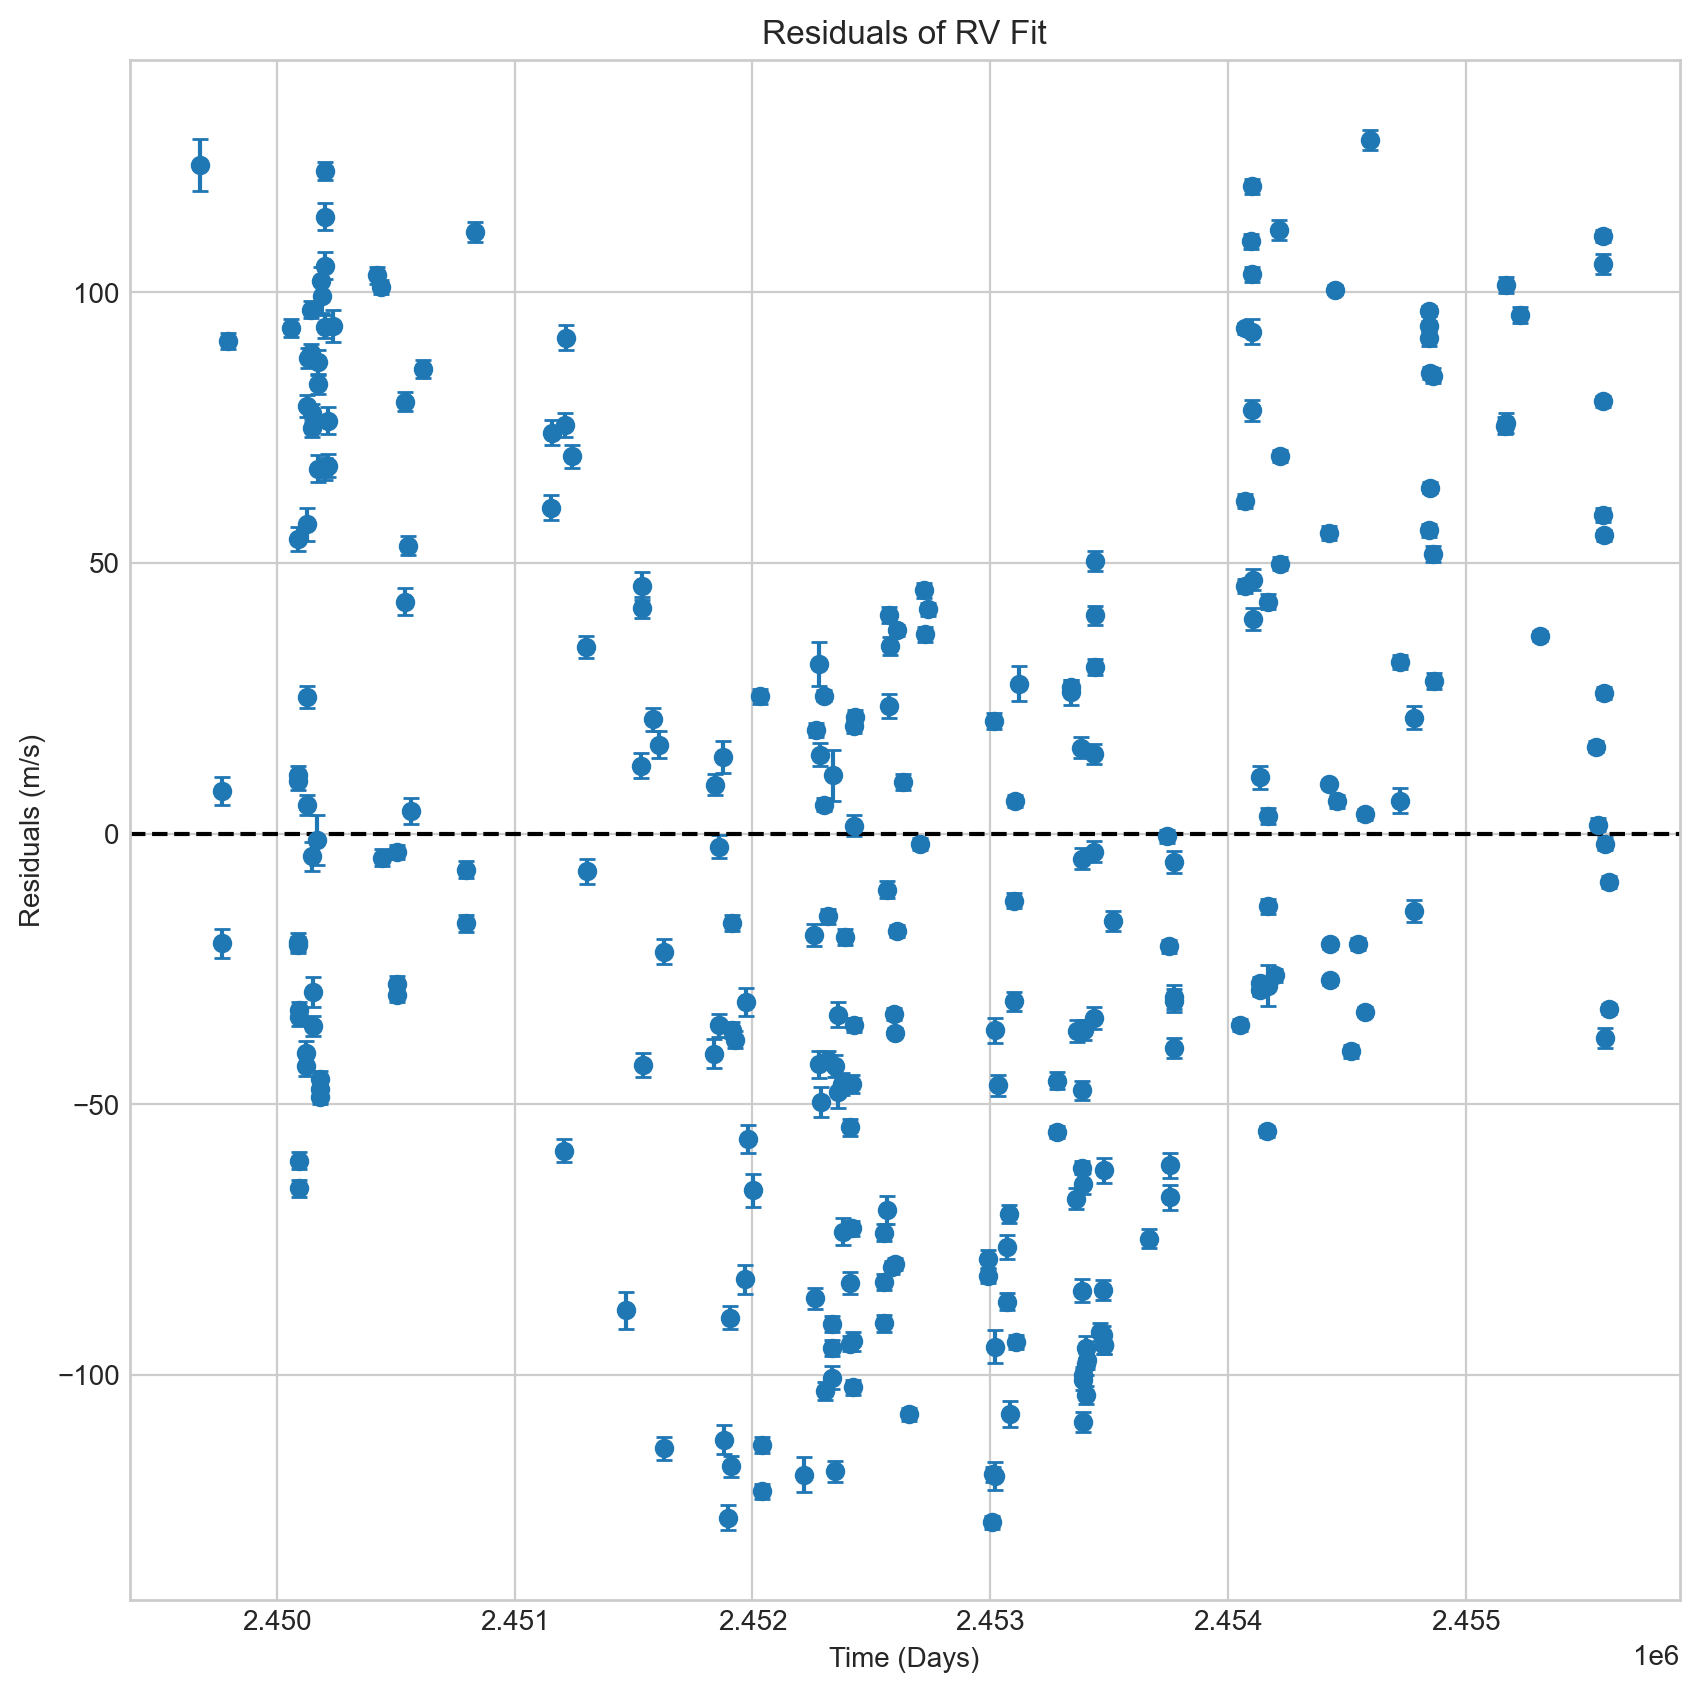

In [4]:
# Model values at observed times
model_values = sinusoid(t, *popt)

# Residuals = data - model
residuals = v - model_values

mpl.figure(figsize=(10,10), dpi=200)
mpl.errorbar(t + t_mean, residuals, yerr=v_err, fmt='o', capsize=3)
mpl.axhline(0, color='black', linestyle='--')
mpl.xlabel("Time (Days)")
mpl.ylabel("Residuals (m/s)")
mpl.title("Residuals of RV Fit")
mpl.show()

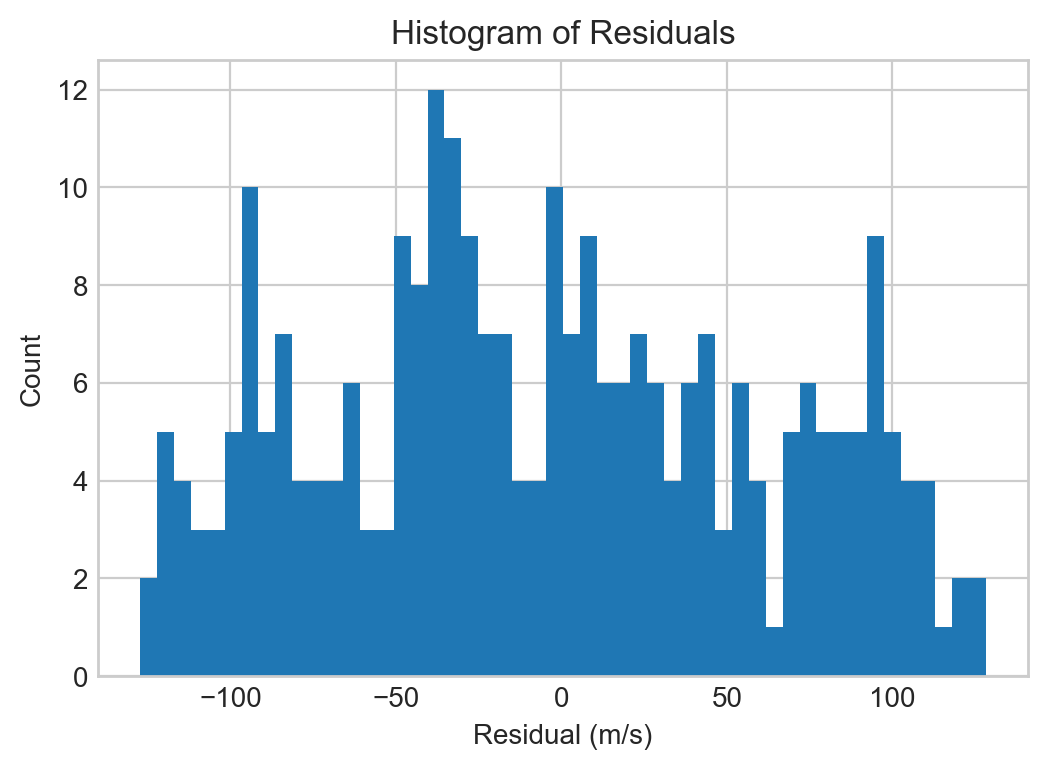

In [5]:
mpl.figure(figsize=(6,4), dpi=200)
mpl.hist(residuals, bins=50)
mpl.xlabel("Residual (m/s)")
mpl.ylabel("Count")
mpl.title("Histogram of Residuals")

mpl.show()

In [6]:
residual_std = np.std(residuals, ddof=1)
mean_error = np.mean(v_err)

print("Std Dev of Residuals =", residual_std)
print("Mean Experimental Uncertainty =", mean_error)

Std Dev of Residuals = 65.52489106313463
Mean Experimental Uncertainty = 1.8060667343065693


In [7]:
chi2 = np.sum((residuals / v_err)**2)
dof = len(v) - len(popt)
reduced_chi2 = chi2 / dof

print("Reduced Chi-Squared =", reduced_chi2)

Reduced Chi-Squared = 1731.1651681907658


In [8]:
A_fit = popt[0]          # amplitude (m/s)
omega_fit = popt[1]
P_fit = 2 * np.pi / omega_fit

In [9]:
K = np.abs(A_fit)
P = 2 * np.pi / np.abs(omega_fit)
M_star = 1.0

M_planet = (K / 28.4) * (P / 365)**(1/3) * (M_star)**(2/3)

print("Planet Mass (in Jupiter masses) =", M_planet)

Planet Mass (in Jupiter masses) = 1.1696748414175409


The exoplanet discovered is HAT-P-37 b